In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import yfinance as yf
from tqdm import tqdm
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from sklearn.linear_model import LinearRegression

nltk.download("vader_lexicon", quiet=True)
plt.style.use("ggplot")

In [2]:
# 1. Initialize Models
sia = SentimentIntensityAnalyzer()
print("Loading FinBERT model...")
finbert = pipeline("sentiment-analysis",model="ProsusAI/finbert")

Loading FinBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# 2. Load Dataset (TSLA Tweets)
df = pd.read_csv("/content/stock_tweets.csv", header=None)
df.columns = ["date","review","ticker","company"]

tsla_df = df[df["ticker"]=="TSLA"].copy()
tsla_df["date"] = pd.to_datetime(tsla_df["date"]).dt.tz_localize(None)
tsla_df = tsla_df[(tsla_df["date"] >= "2021-09-30") & (tsla_df["date"] <= "2022-09-29")]

In [4]:
# 3. Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"@\w+","",text)
    text = re.sub(r"#","",text)
    text = re.sub(r"[^a-z\s]","",text)
    return text.strip()

tsla_df["clean_text"] = tsla_df["review"].apply(clean_text)
tsla_df = tsla_df[tsla_df["clean_text"].str.len() > 5]

In [5]:
# 4. Sentiment Scoring Functions
def vader_score(text):
    return sia.polarity_scores(str(text))["compound"]

def finbert_score(text):
    try:
        # FIX: Added truncation to prevent long-text errors
        result = finbert(str(text), truncation=True, max_length=512)[0]
        if result["label"] == "positive": return 1
        elif result["label"] == "negative": return -1
        return 0
    except:
        return 0

In [6]:
# 5. Robustness Testing Setup (Counterfactuals)
FLIP_DICT = {"bullish":"bearish", "bearish":"bullish", "positive":"negative", "negative":"positive",
             "buy":"sell", "sell":"buy", "up":"down", "down":"up"}

def generate_counterfactual(text):
    text_lower = text.lower()
    new_text = text
    for k,v in FLIP_DICT.items():
        pattern = r'\b' + re.escape(k) + r'\b'
        if re.search(pattern,text_lower):
            new_text = re.sub(pattern,v,new_text)
    return new_text

tsla_df["counterfactual_text"] = tsla_df["clean_text"].apply(generate_counterfactual)

In [7]:
# 6. Evaluation (Adversarial)
print("Running comparative adversarial evaluation...")
test_df = tsla_df[tsla_df["clean_text"].apply(vader_score).abs() > 0.2].sample(n=1000, random_state=42).reset_index(drop=True)

orig_preds, cf_preds = [], []
vader_orig, vader_cf = [], []

for text, cf_text in tqdm(zip(test_df["clean_text"], test_df["counterfactual_text"]), total=len(test_df)):
    orig_preds.append(finbert_score(text))
    cf_preds.append(finbert_score(cf_text))
    vader_orig.append(vader_score(text))
    vader_cf.append(vader_score(cf_text))

test_df["fin_orig"], test_df["fin_cf"] = orig_preds, cf_preds
test_df["vader_orig"], test_df["vader_cf"] = vader_orig, vader_cf

Running comparative adversarial evaluation...


100%|██████████| 1000/1000 [07:03<00:00,  2.36it/s]


In [8]:
# 7. Calculate LRS (Logic Robustness Score)
# Robust means sentiment flipped (original * flipped < 0)
fin_valid = test_df[test_df["fin_orig"] != 0]
fin_lrs = ((fin_valid["fin_orig"] * fin_valid["fin_cf"]) < 0).mean()

vader_valid = test_df[test_df["vader_orig"] != 0]
vader_lrs = ((vader_valid["vader_orig"] * vader_valid["vader_cf"]) < 0).mean()

print(f"\nFinal Results on TSLA Dataset:")
print(f"FinBERT LRS: {fin_lrs:.4f}")
print(f"VADER LRS: {vader_lrs:.4f}")
print(f"Logic Gap: {fin_lrs - vader_lrs:.4f}")


Final Results on TSLA Dataset:
FinBERT LRS: 0.0843
VADER LRS: 0.0060
Logic Gap: 0.0783


In [11]:
# 8. Export Data & Identify "Logic Failures"
# A "Failure" is defined as cases where the model fails to flip its
# sentiment prediction after the key financial terms were reversed.
# (i.e., the product of original and flipped predictions is >= 0)
tsla_failures = test_df[(test_df["fin_orig"] * test_df["fin_cf"]) >= 0]
tsla_failures.to_csv("tsla_finbert_logic_failures.csv", index=False)

print("Fetching market price data via yfinance...")
# Download TSLA historical stock prices
price = yf.download("TSLA", start="2021-09-30", end="2022-09-30", progress=False)

# Newer versions of yfinance return a MultiIndex (e.g., [('Close', 'TSLA')]).
# We must flatten it to a single level to match our 'daily' dataframe structure.
if isinstance(price.columns, pd.MultiIndex):
    price.columns = price.columns.get_level_values(0)

# Reset index to move 'Date' into a column and calculate daily returns
price = price.reset_index()
price["day"] = price["Date"].dt.date
price["return"] = price["Close"].pct_change()

# Aggregate sentiment scores by day (mean value)
daily = tsla_df.groupby(tsla_df["date"].dt.date)["clean_text"].apply(
    lambda x: x.apply(vader_score).mean()
).reset_index()
daily.columns = ["day", "sentiment_score"]

# Merge sentiment signals with stock returns.
merged = pd.merge(daily, price[["day","return"]], on="day", how="inner").dropna()

# Export finalized correlation data to create paper visualizations
merged.to_csv("tsla_market_correlation.csv", index=False)

print("\n[SUCCESS] All artifacts (CSVs) exported for the team.")

Fetching market price data via yfinance...


/tmp/ipykernel_2435/3697894559.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download("TSLA", start="2021-09-30", end="2022-09-30", progress=False)



[SUCCESS] All artifacts (CSVs) exported for the team.


In [13]:
# Load the original failure list
df = pd.read_csv('tsla_finbert_logic_failures.csv')

# Define "True Logic Failures" filtering criteria:
# Criteria A: The text must have actually changed (keywords were found and flipped).
# Criteria B: The original sentiment must not be Neutral (the model had a clear stance to begin with).
true_failures = df[
    (df['clean_text'] != df['counterfactual_text']) &
    (df['fin_orig'] != 0)
].copy()

# Save to a refined CSV specifically for Qualitative Analysis
true_failures.to_csv('tsla_true_logic_failures.csv', index=False)

# Summary statistics
print(f"Original failure records: {len(df)}")
print(f"Refined 'True Logic Failures': {len(true_failures)}")
print("\n--- Top Samples for Qualitative Analysis ---")
print(true_failures[['clean_text', 'counterfactual_text', 'fin_orig', 'fin_cf']].head())

Original failure records: 979
Refined 'True Logic Failures': 51

--- Top Samples for Qualitative Analysis ---
                                           clean_text  \
3   tsla setting up for a pull back to  by next we...   
9   the goro mine in new caledonia  the tiny islan...   
16  i know  not knocking you  just annoyed by the ...   
19  why would ark sell tsla to buy roku\nmy first ...   
42  it is funny watching tsla sometimes when marke...   

                                  counterfactual_text  fin_orig  fin_cf  
3   tsla setting down for a pull back to  by next ...        -1      -1  
9   the goro mine in new caledonia  the tiny islan...         1       1  
16  i know  not knocking you  just annoyed by the ...        -1      -1  
19  why would ark buy tsla to buy roku\nmy first r...         1       1  
42  it is funny watching tsla sometimes when marke...        -1       0  


"The 979 'failures' in the CSV are actually raw data.

Most of them (813 cases) are just because the tweets didn't contain our specific keywords, so the text didn't change. Another huge chunk (751 cases) were Neutral to begin with.

The real 'Gold' is the 51 cases where the logic actually flipped but the model didn't catch it. This shows us exactly where FinBERT’s limitations are—like when the overall sentence context is so strong that it ignores a single word change.

We should focus analysis on these 51 'True Logic Failures' to explain the model's blind spots. This will make our qualitative analysis very deep and academic."

**Visualization**

Generated: tsla_sentiment_vs_return_timeseries.png


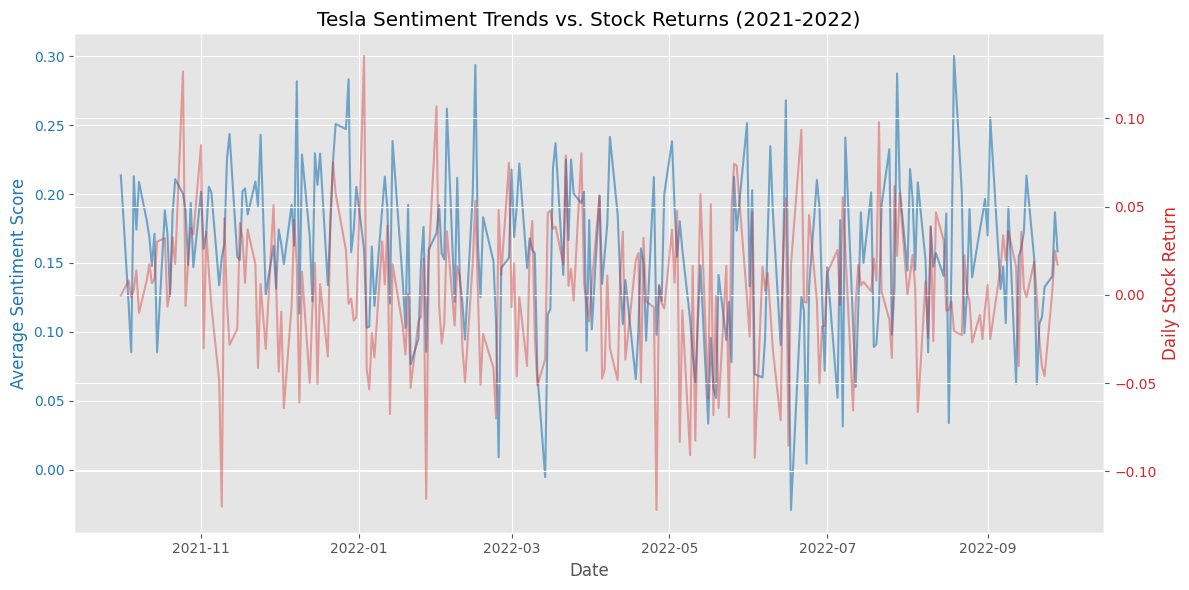

In [14]:
# 1. Load the market correlation data
df_market = pd.read_csv('tsla_market_correlation.csv')
df_market['day'] = pd.to_datetime(df_market['day'])

# Visual 1: Dual-Axis Time Series (Sentiment vs Returns)
# Purpose: To show the daily fluctuations of sentiment alongside stock returns.
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Sentiment Score', color=color)
ax1.plot(df_market['day'], df_market['sentiment_score'], color=color, alpha=0.6, label='Sentiment')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Daily Stock Return', color=color)
ax2.plot(df_market['day'], df_market['return'], color=color, alpha=0.4, label='Stock Return')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tesla Sentiment Trends vs. Stock Returns (2021-2022)')
fig.tight_layout()
plt.savefig('tsla_sentiment_vs_return_timeseries.png', dpi=300)
print("Generated: tsla_sentiment_vs_return_timeseries.png")

Generated: tsla_sentiment_return_correlation.png


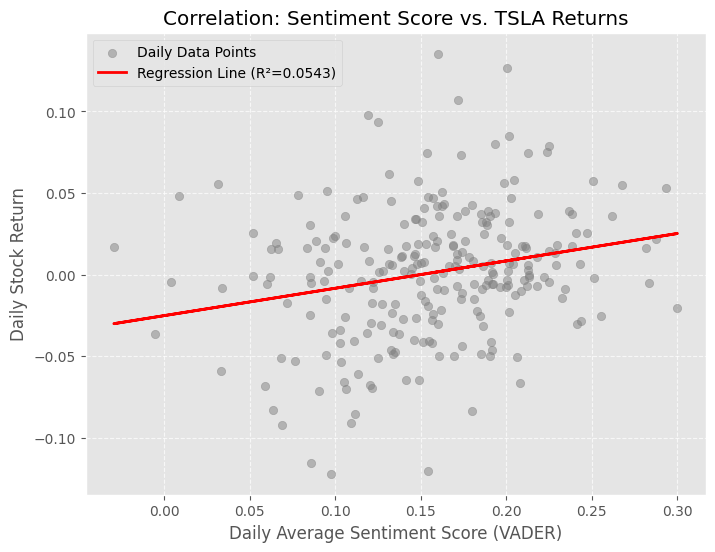

In [15]:
# Visual 2: Correlation Scatter Plot with Regression Line
# Purpose: To visualize the statistical relationship between sentiment and returns.
X = df_market[['sentiment_score']].values
y = df_market['return'].values

# Calculate Linear Regression
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r_squared = reg.score(X, y)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, color='gray', label='Daily Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line (R²={r_squared:.4f})')
plt.xlabel('Daily Average Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return')
plt.title('Correlation: Sentiment Score vs. TSLA Returns')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('tsla_sentiment_return_correlation.png', dpi=300)
print("Generated: tsla_sentiment_return_correlation.png")

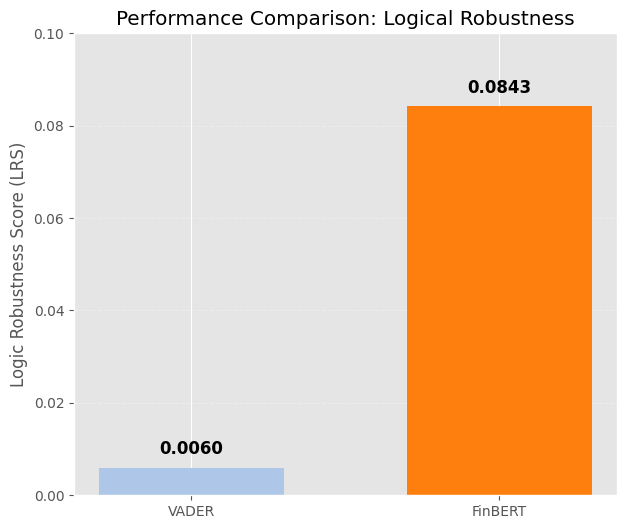

In [18]:
# Visual 3: LRS Comparison Bar Chart (FinBERT vs VADER)
# Purpose: The "Killer Plot" showing FinBERT's superior logic robustness.
# Using the values from your successful run: FinBERT (0.0843) vs VADER (0.0060)
lrs_results = {
    'Model': ['VADER', 'FinBERT'],
    'LRS': [0.0060, 0.0843]
}
df_lrs = pd.DataFrame(lrs_results)

plt.figure(figsize=(7, 6))
colors = ['#aec7e8', '#ff7f0e'] # Professional blue and orange
bars = plt.bar(df_lrs['Model'], df_lrs['LRS'], color=colors, width=0.6)

# Adding value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylabel('Logic Robustness Score (LRS)')
plt.title('Performance Comparison: Logical Robustness')
plt.ylim(0, 0.1) # Set limit to provide visual breathing room
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('lrs_comparison_bar_chart.png', dpi=300)